In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset of five Classes

In [43]:

#df = pd.read_csv("/content/synthetic_dataset.csv")

np.random.seed(0)
points_per_class = 300

# Generate 5 clusters with distinct centers
class_0 = np.random.randn(points_per_class, 2) + np.array([0, 0])
class_1 = np.random.randn(points_per_class, 2) + np.array([5, 0])
class_2 = np.random.randn(points_per_class, 2) + np.array([0, 5])
class_3 = np.random.randn(points_per_class, 2) + np.array([5, 5])
class_4 = np.random.randn(points_per_class, 2) + np.array([2.5, 2.5])

# Combine all points
X = np.vstack((class_0, class_1, class_2, class_3, class_4))


_Y = np.array([0]*points_per_class + [1]*points_per_class +
                 [2]*points_per_class + [3]*points_per_class + [4]*points_per_class)


num_classes = 5
Y = np.zeros((_Y.size, num_classes))
Y[np.arange(_Y.size), _Y] = 1


print(X.shape)
print(Y.shape)
print(np.unique(_Y))


(1500, 2)
(1500, 5)
[0 1 2 3 4]


# Visulize data on Scatter Plot

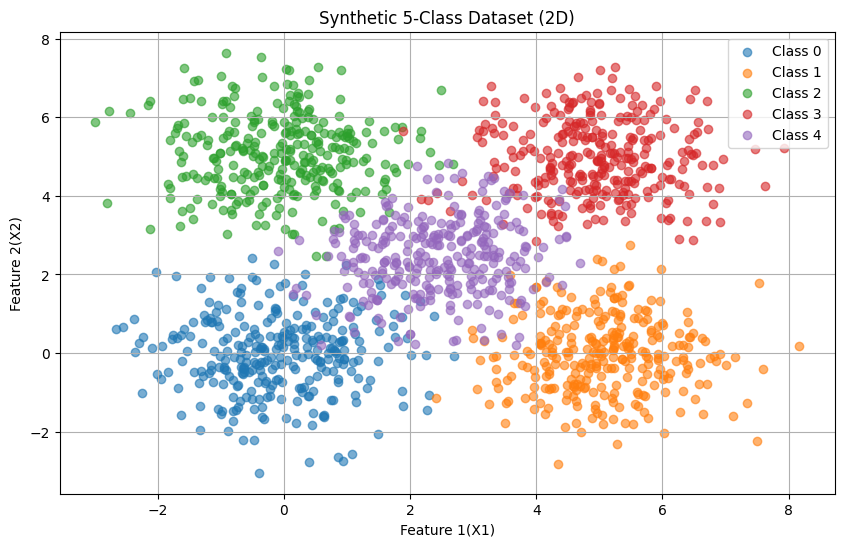

In [72]:
plt.figure(figsize=(10, 6))
for c in range(num_classes):
    plt.scatter(X[_Y == c, 0], X[_Y == c, 1], label=f"Class {c}", alpha=0.6)
plt.xlabel("Feature 1(X1)")
plt.ylabel("Feature 2(X2)")
plt.title("Synthetic 5-Class Dataset (2D)")
plt.legend()
plt.grid(True)
plt.show()


# Create 3 hidden layer

In [59]:
class NeuralNetwork_threeLayer(object):
    def __init__(self, hidden1, hidden2, hidden3):
        inputLayerNeurons = 2
        outLayerNeurons = 5   # 5 classes
        self.learning_rate = 0.2

        self.W1 = np.random.randn(inputLayerNeurons, hidden1)
        self.W2 = np.random.randn(hidden1, hidden2)
        self.W3 = np.random.randn(hidden2, hidden3)
        self.W4 = np.random.randn(hidden3, outLayerNeurons)   # output layer

    def sigmoid(self, x, der=False):
        if der:
            return x * (1 - x)
        return 1 / (1 + np.exp(-x))

    # FeedForward
    def feedForward(self, X):
        self.Z1 = np.dot(X, self.W1)
        self.A1 = self.sigmoid(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2)
        self.A2 = self.sigmoid(self.Z2)

        self.Z3 = np.dot(self.A2, self.W3)
        self.A3 = self.sigmoid(self.Z3)

        self.Z4 = np.dot(self.A3, self.W4)
        self.pred = self.sigmoid(self.Z4)

        return self.pred

    # BackPropagation
    def backPropagation(self, X, Y, pred):
        output_error = Y - pred
        delta4 = self.learning_rate * output_error * self.sigmoid(pred, der=True)

        error3 = delta4.dot(self.W4.T)
        delta3 = self.learning_rate * error3 * self.sigmoid(self.A3, der=True)

        error2 = delta3.dot(self.W3.T)
        delta2 = self.learning_rate * error2 * self.sigmoid(self.A2, der=True)

        error1 = delta2.dot(self.W2.T)
        delta1 = self.learning_rate * error1 * self.sigmoid(self.A1, der=True)

        # update weights
        self.W4 += self.A3.T.dot(delta4)
        self.W3 += self.A2.T.dot(delta3)
        self.W2 += self.A1.T.dot(delta2)
        self.W1 += X.T.dot(delta1)

    # train
    def train(self, X, Y):
        output = self.feedForward(X)
        self.backPropagation(X, Y, output)

    def accuracy(self, X, Y):
        predictions = self.feedForward(X)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = np.argmax(Y, axis=1)
        return np.mean(predicted_classes == true_classes)

    def confusion_matrix(self, X, Y):
        predictions = self.feedForward(X)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = np.argmax(Y, axis=1)

        num_classes = Y.shape[1]
        conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

        for true, pred in zip(true_classes, predicted_classes):
            conf_matrix[true, pred] += 1

        return conf_matrix


# Accuracy, error, confusion matrix

In [63]:
hidden1 = 10
hidden2 = 8
hidden3 = 6

NN = NeuralNetwork_threeLayer(hidden1, hidden2, hidden3)

err = []
acc = []

for i in range(200):
    NN.train(X, Y)
    error = np.mean(np.square(Y - NN.feedForward(X)))
    err.append(error)

    accuracy = NN.accuracy(X, Y)
    acc.append(accuracy)

conf_matrix = NN.confusion_matrix(X, Y)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[270   4   1   0  25]
 [  0 287   0   4   9]
 [  0   0 289   8   3]
 [  0   0   1 298   1]
 [  5  10   6 145 134]]


# Plot the confusion matrix

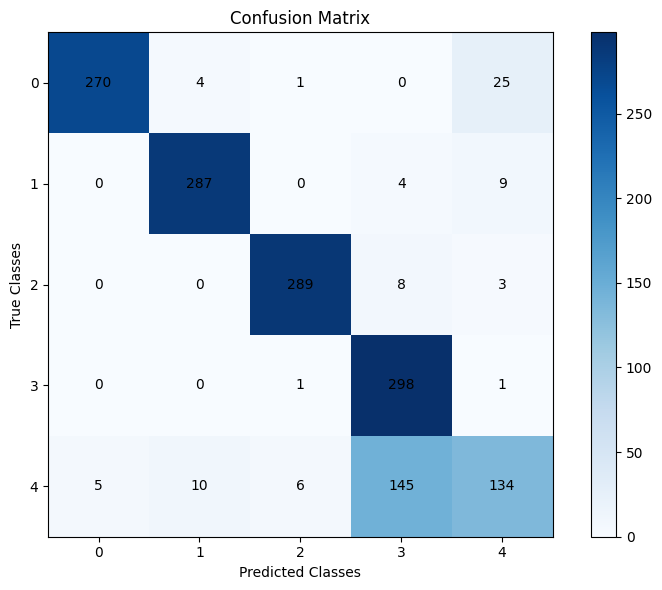

In [77]:
conf_matrix = NN.confusion_matrix(X, Y)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(ticks=range(conf_matrix.shape[1]), labels=range(conf_matrix.shape[1]))
plt.yticks(ticks=range(conf_matrix.shape[0]), labels=range(conf_matrix.shape[0]))
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.title('Confusion Matrix')

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# Plot Accuracy and Loss

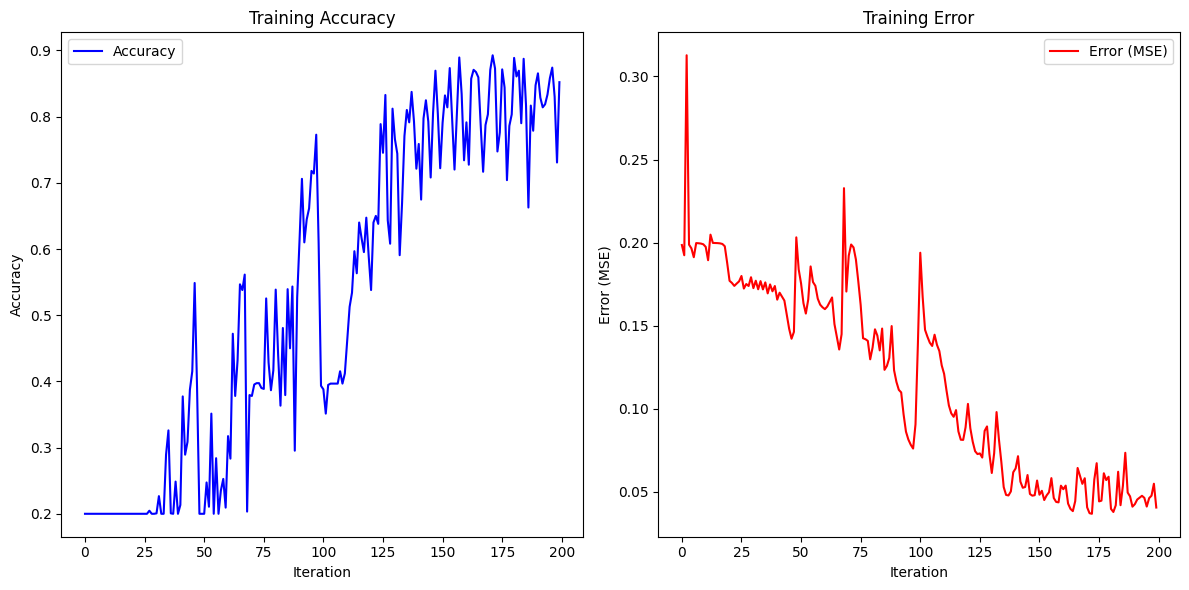

In [78]:
# Plotting error and accuracy in subplots
plt.figure(figsize=(12, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Accuracy', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

# Error subplot
plt.subplot(1, 2, 2)
plt.plot(err, label='Error (MSE)', color='red')
plt.xlabel('Iteration')
plt.ylabel('Error (MSE)')
plt.title('Training Error')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

# Test

In [79]:
np.random.seed(24)
test_points_per_class = 100

# Generate 5 test clusters
test_class_0 = np.random.randn(test_points_per_class, 2) + np.array([0, 0])
test_class_1 = np.random.randn(test_points_per_class, 2) + np.array([5, 0])
test_class_2 = np.random.randn(test_points_per_class, 2) + np.array([0, 5])
test_class_3 = np.random.randn(test_points_per_class, 2) + np.array([5, 5])
test_class_4 = np.random.randn(test_points_per_class, 2) + np.array([2.5, 2.5])

# Combine test data
X_test = np.vstack((test_class_0, test_class_1, test_class_2, test_class_3, test_class_4))

# Raw labels (0–4)
Y_test_raw = np.array(
    [0]*test_points_per_class +
    [1]*test_points_per_class +
    [2]*test_points_per_class +
    [3]*test_points_per_class +
    [4]*test_points_per_class
)

# One-hot encode (5 classes)
Y_test = np.zeros((Y_test_raw.size, 5))
Y_test[np.arange(Y_test_raw.size), Y_test_raw] = 1

# Evaluate test accuracy
test_accuracy = NN.accuracy(X_test, Y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Test confusion matrix
conf_matrix_test = NN.confusion_matrix(X_test, Y_test)
print("Confusion Matrix (Test):")
print(conf_matrix_test)


Test Accuracy: 0.8480
Confusion Matrix (Test):
[[ 90   1   0   0   9]
 [  0  97   0   2   1]
 [  0   0  98   1   1]
 [  0   0   0 100   0]
 [  1   3   4  53  39]]


# Confusion matrix for Test Data

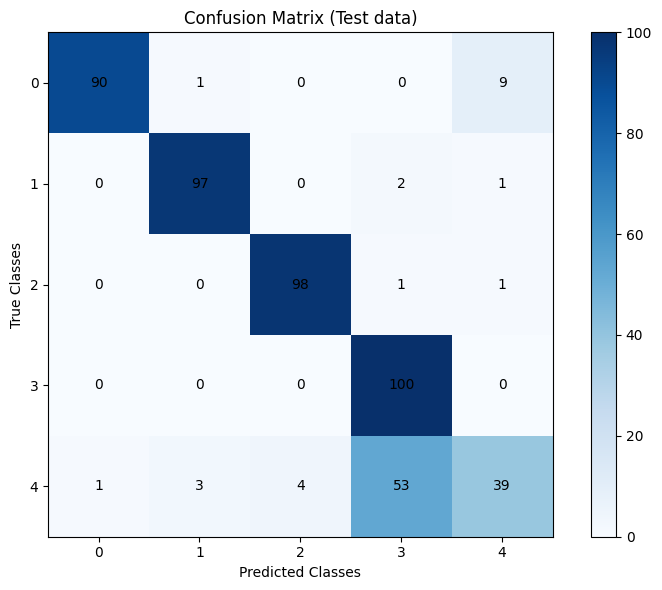

In [81]:
conf_matrix = NN.confusion_matrix(X_test, Y_test)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(ticks=range(conf_matrix.shape[1]), labels=range(conf_matrix.shape[1]))
plt.yticks(ticks=range(conf_matrix.shape[0]), labels=range(conf_matrix.shape[0]))
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.title('Confusion Matrix (Test data)')

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# Result
**Class 0:**

* 90 correctly predicted
* 9 misclassified as Class 4
* 1 misclassified as Class 1

**Class 1:**
* 97 correct
* 2 misclassified as Class 3
* 1 misclassified as Class 4

**Class 2:**
* 98 correct
* 1 misclassified as Class 3
* 1 misclassified as Class 4

**Class 3:**

* 100 correct → perfect

**Class 4:**

* Only 39 correct
* Most misclassified as Class 3 (53), some as Class 1 or 2

**Model correctly predicts ~85% of the test points.**